<a href="https://colab.research.google.com/github/LFRMontreuil67/1.4-Git-Github-challenge/blob/master/Copie_de_Matplolib_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Execute the code below

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt

link = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/weather2019.csv"
df_weather = pd.read_csv(link).iloc[:,[0, 1, 2, -3]]

df_weather['DATE'] = pd.to_datetime(df_weather['DATE'])
df_weather['DATE'].dt.month.value_counts().sort_index()

,count
DATE,
1,31
2,28
3,31
4,30
5,31
6,30
7,31
8,31
9,30


# You have now a DataFrame with weather data

In [ ]:
df_weather.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,OPINION
0,2019-01-01,9,4,very bad
1,2019-01-02,8,5,very bad
2,2019-01-03,6,0,very bad
3,2019-01-04,5,-1,very bad
4,2019-01-05,6,-1,very bad


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_weather)

https://docs.google.com/spreadsheets/d/1v9JmMO5NMZl6hc1ScuiVuv2zriViIvQifAYUqJdqV0M/edit#gid=0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_weather)

https://docs.google.com/spreadsheets/d/1iyMAKk5jDubXceJq9P8Rcrs04SUuVXEAGxJ6KgJ2miM/edit#gid=0


# Now, complete the following tasks :


## 4 charts
You have to show a figure with 4 subplots :
- For the top left one : scatterplot with MAX (in red) and MIN (in blue) Temperatures (Y-axis), and date on X-axis
- For the top right one : [a pie-chart ](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.pie.html)with frequencies of opinions. Could you "explode" the "very good" part ?
- For the bottom left one : a zoom on january, with MAX Temperatures on a column chart (bar), and MIN temperature on a curve (plot). Date on X-axis.
- For the bottom right one : [an histogram ](https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.pyplot.hist.html)with MAX Temperatures on X-axis.

Each chart must have a title, a legend for the colors, and of course, readable axis (ticks)

Here is an example of what is expected :

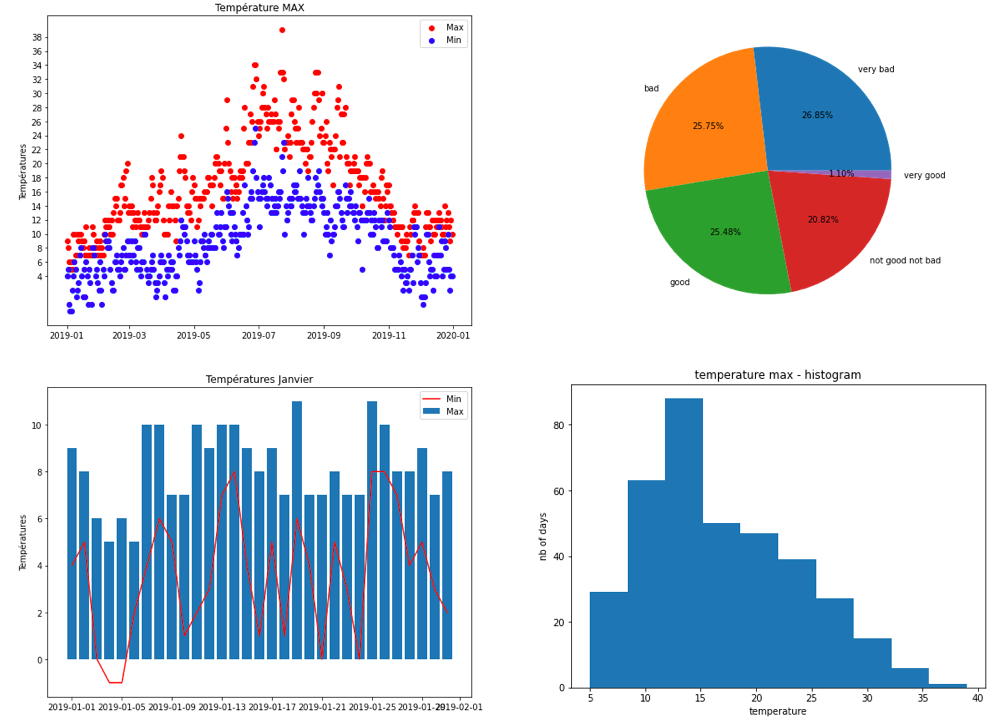

OPINION
very bad            98
bad                 94
good                93
not good not bad    76
very good            4
Name: count, dtype: int64
Index :  None
Columns :  Index(['DATE', 'MAX_TEMPERATURE_C', 'MIN_TEMPERATURE_C', 'OPINION'], dtype='object')


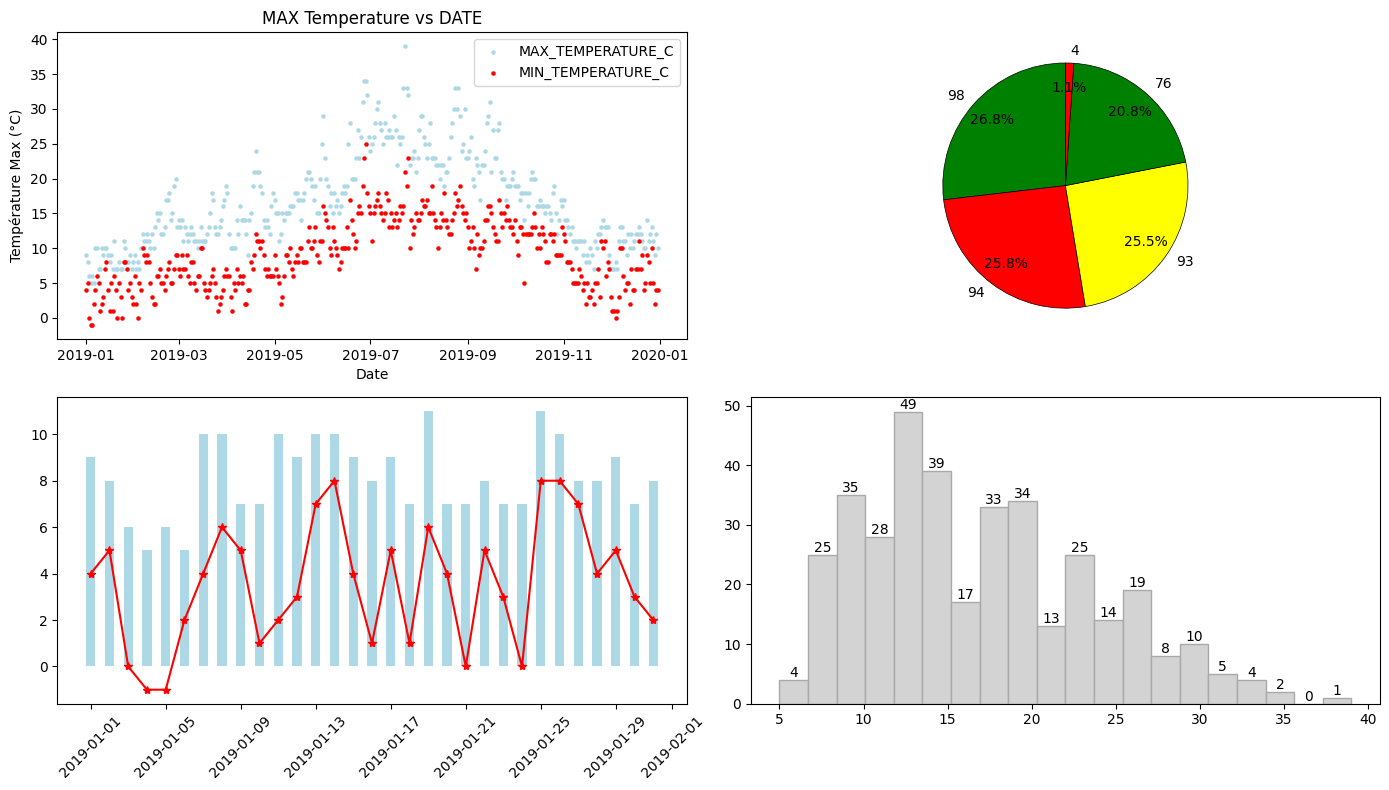

In [ ]:
# Complete the code below :
print(df_weather['OPINION'].value_counts()) # Hey, value_counts() seems a good method for the pie. How can I use it ?

print('Index : ', df_weather.index.name)
print('Columns : ', df_weather.columns)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 8))

# scatterplot with MAX (in red) and MIN (in blue) Temperatures (Y-axis), and date on X-axis
ax1.scatter(df_weather["DATE"], df_weather['MAX_TEMPERATURE_C'], color='lightblue', label='MAX_TEMPERATURE_C', s=5)
ax1.scatter(df_weather["DATE"], df_weather['MIN_TEMPERATURE_C'], color='red', label='MIN_TEMPERATURE_C', s=5)
ax1.set_xlabel("Date")
ax1.set_ylabel("Température Max (°C)")
ax1.set_title("MAX Temperature vs DATE")
ax1.legend(loc='upper right')

# For the top right one : a pie-chart with frequencies of opinions
ax2.pie(
    df_weather["OPINION"].value_counts(),
    labels=df_weather["OPINION"].value_counts(),

    autopct='%1.1f%%',  # Pourcentages avec 1 décimale
    startangle=90,  # Rotation de départ
    colors=['green', 'red', 'yellow'],  # Couleurs personnalisées
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},  # Bordures noires de 1.5pt
    textprops={'fontsize': 10},  # Taille de la police des labels
    pctdistance=0.8  # Distance des pourcentages par rapport au centre
    )

# For the bottom left one : a zoom on january, with MAX Temperatures on a column chart (bar), and MIN temperature on a curve (plot).
ax3.bar(
    df_weather[df_weather['DATE'].dt.month == 1] ['DATE'],
    df_weather[df_weather['DATE'].dt.month == 1] ['MAX_TEMPERATURE_C'],
    color='lightblue',
    label='MAX Temperature (°C)',
    width=0.5,  # Largeur des barres pour éviter le chevauchement
)
ax3.tick_params(axis='x', rotation=45)
ax3.plot(
    df_weather[df_weather['DATE'].dt.month == 1] ['DATE'],
    df_weather[df_weather['DATE'].dt.month == 1] ['MIN_TEMPERATURE_C'],
    color='red',
    marker='*',
    label='Min Temp (°C)'
)

# For the bottom right one : an histogram with MAX Temperatures on X-axis.
ax4.hist(
    df_weather['MAX_TEMPERATURE_C'],
    bins=20,
    color='lightgrey',
    edgecolor='darkgrey'
)

for bar in ax4.patches:
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()



## Boxplots and outliers

Plot 2 [boxplots](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.boxplot.html) :
1. on the MIN temperature
2. on the MAX temperature

Are there outliers? OUI 1 seul

In [ ]:
" """""""""""""""""""""""""""""""""""""""""""""""""""""
# Ajout de nouveaux Outliers (autour de la valeur max)
" """""""""""""""""""""""""""""""""""""""""""""""""""""
maxTemp = df_weather['MAX_TEMPERATURE_C'].max()
print('Max : ', maxTemp)
df_weather[df_weather['MAX_TEMPERATURE_C'] == maxTemp][['DATE', 'MAX_TEMPERATURE_C']]
df_weather.iloc[203, 1] = 39
df_weather[df_weather['MAX_TEMPERATURE_C'] == maxTemp].index

ligne_203 = df_weather.iloc[[203]]
df_weather=pd.concat([df_weather, ligne_203])
df_weather = df_weather.reset_index(drop=True)

# Détection de l'outlier
Q1 = df_weather['MAX_TEMPERATURE_C'].quantile(0.25)
Q3 = df_weather['MAX_TEMPERATURE_C'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_weather[
    (df_weather['MAX_TEMPERATURE_C'] < Q1 - 1.5 * IQR) |
    (df_weather['MAX_TEMPERATURE_C'] > Q3 + 1.5 * IQR)
]

print('Q1 : ', Q1)
print('Q3 : ', Q3)
print('IQR : ', IQR)

# détecter les outliers :
outliers = df_weather[
    (df_weather['MAX_TEMPERATURE_C'] < Q1 - 1.5 * IQR) |
    (df_weather['MAX_TEMPERATURE_C'] > Q3 + 1.5 * IQR)
]

# Garder les Outliers sous la forme d'une d'index (pour plus tard) :
lstOutliers = outliers.index.tolist()

print('Les outliers : \n',lstOutliers)

Max :  39
Q1 :  11.25
Q3 :  21.0
IQR :  9.75
Les outliers : 
 [203, 365]


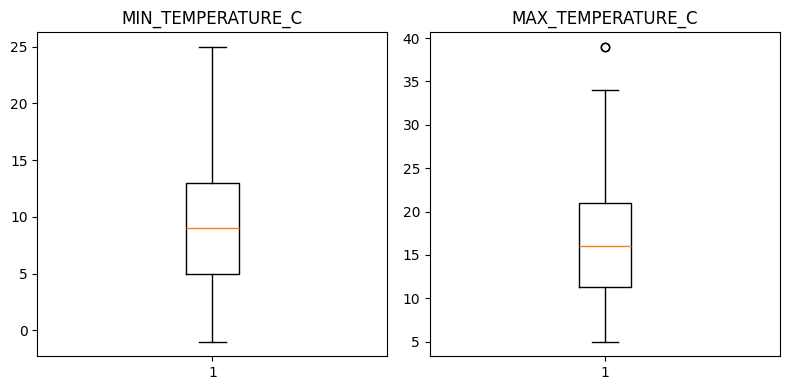

In [ ]:
import warnings
warnings.filterwarnings("ignore")
" """""""""""""""""""""""""""""""""""""""""""""""""""""
# Affichage des PlotBox
" """""""""""""""""""""""""""""""""""""""""""""""""""""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.set_title('MIN_TEMPERATURE_C')
ax1.boxplot(df_weather['MIN_TEMPERATURE_C'])
ax2.set_title('MAX_TEMPERATURE_C')
ax2.boxplot(df_weather['MAX_TEMPERATURE_C'])
plt.tight_layout()
plt.show()

Suppression des outliers


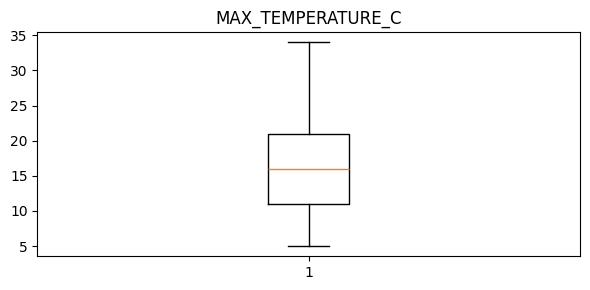

Les outliers : 
 [203, 365]


In [ ]:
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# Suppression des outliers : on exclut les rows à l'extérieur des seuils inférieurs et supérieurs
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
print('Suppression des outliers')
dfw_CleanedUp = df_weather.copy()
dfw_CleanedUp = dfw_CleanedUp[
    (dfw_CleanedUp['MAX_TEMPERATURE_C'] >= dfw_CleanedUp['MAX_TEMPERATURE_C'].quantile(0.25) - 1.5*IQR) &
    (dfw_CleanedUp['MAX_TEMPERATURE_C'] <= dfw_CleanedUp['MAX_TEMPERATURE_C'].quantile(0.75) + 1.5*IQR)
]
fig, ax = plt.subplots(1, figsize=(6, 3))
ax.set_title('MAX_TEMPERATURE_C')
ax.boxplot(dfw_CleanedUp['MAX_TEMPERATURE_C'])
plt.tight_layout()
plt.show()
print('Les outliers : \n',lstOutliers)

Cliper les outliers sur les seuils inférieur et supérieur (lower_bound, upper_bound)
lower_bound :  -3.375
upper_bound :  35.625

Liste des outliers : 
           DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C           OPINION
203 2019-07-23             35.625                 21  not good not bad
365 2019-07-23             35.625                 21  not good not bad


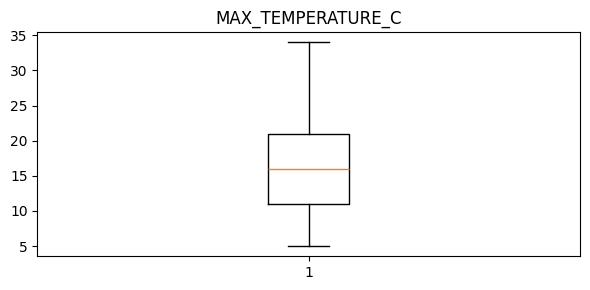

In [ ]:
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# Suppression des outliers : on reporte les outliers sur les seuils inférieur et supérieurs
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
print('Cliper les outliers sur les seuils inférieur et supérieur (lower_bound, upper_bound)')
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

dfw2_CleanedUp = df_weather.copy()
dfw2_CleanedUp.loc[lstOutliers, 'MAX_TEMPERATURE_C'] = dfw2_CleanedUp.loc[lstOutliers, 'MAX_TEMPERATURE_C'].clip(lower_bound, upper_bound)

print('lower_bound : ', lower_bound)
print('upper_bound : ', upper_bound)
print('\nListe des outliers : \n',  dfw2_CleanedUp.loc[lstOutliers])

fig, ax = plt.subplots(1, figsize=(6, 3))
ax.set_title('MAX_TEMPERATURE_C')
ax.boxplot(dfw_CleanedUp['MAX_TEMPERATURE_C'])
plt.tight_layout()
plt.show()

Reporter les outliers sur la médiane (ou la moyenne)
La médiane :  16.0

Avant Liste des outliers : 
           DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C           OPINION
203 2019-07-23                 39                 21  not good not bad
365 2019-07-23                 39                 21  not good not bad

Après : Liste des outliers : 
           DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C           OPINION
203 2019-07-23                 16                 21  not good not bad
365 2019-07-23                 16                 21  not good not bad


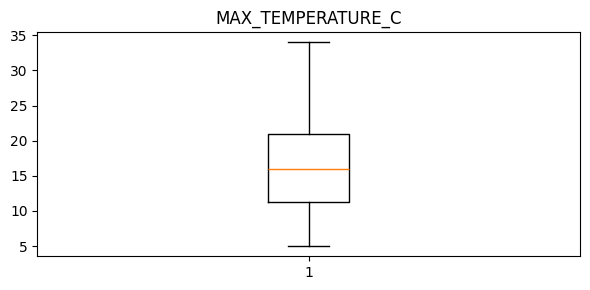

In [ ]:
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# Traitement des outliers : on reporte les rows sur la médiane (ou la moyenne)
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
print('Reporter les outliers sur la médiane (ou la moyenne)')

dfw3_CleanedUp = df_weather.copy()
laMediane = dfw3_CleanedUp['MAX_TEMPERATURE_C'].median()
# laMediane = dfw3_CleanedUp.loc[lstOutliers, 'MAX_TEMPERATURE_C'].median()

print("La médiane : ", laMediane)
print('\nAvant Liste des outliers : \n',  dfw3_CleanedUp.loc[lstOutliers])
dfw3_CleanedUp.loc[lstOutliers, 'MAX_TEMPERATURE_C'] = laMediane
print('\nAprès : Liste des outliers : \n',  dfw3_CleanedUp.loc[lstOutliers])

fig, ax = plt.subplots(1, figsize=(6, 3))
ax.set_title('MAX_TEMPERATURE_C')
ax.boxplot(dfw3_CleanedUp['MAX_TEMPERATURE_C'])
plt.tight_layout()
plt.show()

Reporter les outliers sur la valeur au dessous puis en dessous
          DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C           OPINION
346 2019-12-13               10.0                  2          very bad
347 2019-12-14               12.0                  7               bad
348 2019-12-15               10.0                  4          very bad
349 2019-12-16               11.0                  4          very bad
350 2019-12-17               12.0                  7               bad
351 2019-12-18               12.0                  7               bad
352 2019-12-19               13.0                 11          very bad
353 2019-12-20               12.0                  7          very bad
354 2019-12-21               11.0                  9          very bad
355 2019-12-22               10.0                  4          very bad
356 2019-12-23               10.0                  5          very bad
357 2019-12-24               14.0                  9          very bad
358 2019-12-25

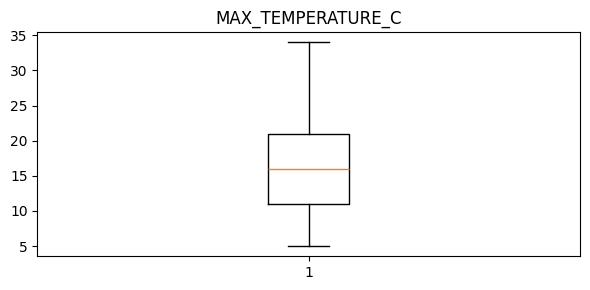


Liste des outliers : 
           DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C           OPINION
203 2019-07-23               33.0                 21  not good not bad
365 2019-07-23               10.0                 21  not good not bad


In [ ]:

# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# Suppression des outliers : on reporte les rows sur les valeurs de la row du dessous puis du dessous
# Boucler sur '.ffill().bfill()' jusqu'a ce que tous les outlirs soient traités.
# """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
print('Reporter les outliers sur la valeur au dessous puis en dessous')

dfw4_CleanedUp = df_weather.copy()
dfw4_CleanedUp.loc[lstOutliers, 'MAX_TEMPERATURE_C'] = np.nan
print(dfw4_CleanedUp.tail(20))
dfw4_CleanedUp.sort_values(by='DATE', ascending=True)
dfw4_CleanedUp['MAX_TEMPERATURE_C'] = dfw4_CleanedUp['MAX_TEMPERATURE_C'].ffill().bfill()

fig, ax = plt.subplots(1, figsize=(6, 3))
ax.set_title('MAX_TEMPERATURE_C')
ax.boxplot(dfw_CleanedUp['MAX_TEMPERATURE_C'])
plt.tight_layout()
plt.show()

print('\nListe des outliers : \n',  dfw4_CleanedUp.loc[lstOutliers])

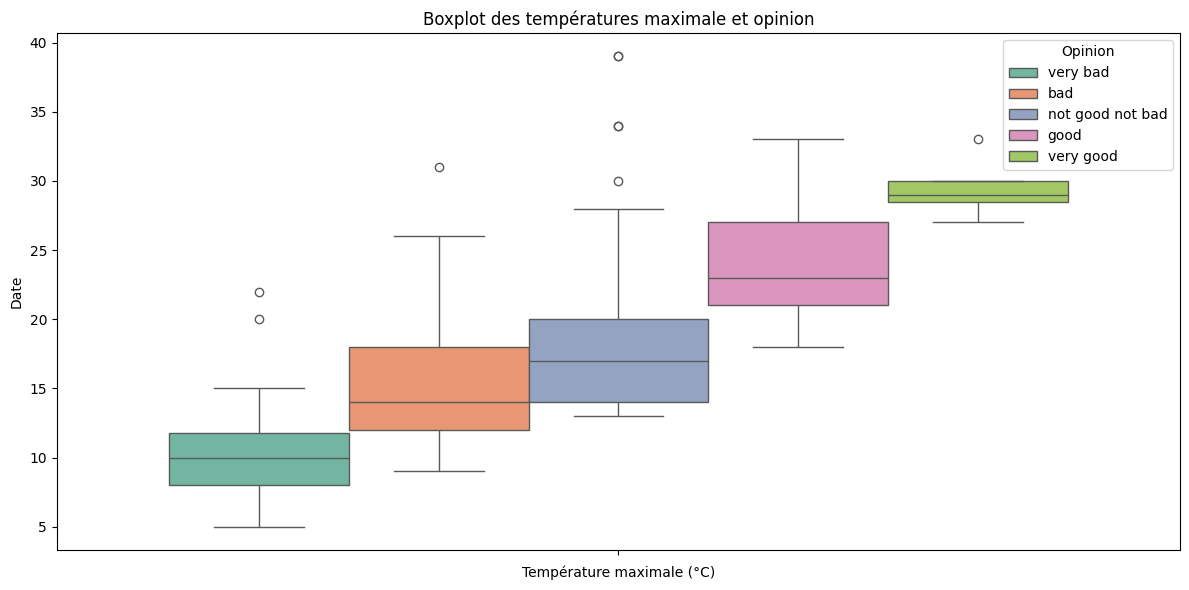

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_weather,
    y="MAX_TEMPERATURE_C",
    hue="OPINION",
    palette="Set2"
)

plt.title("Boxplot des températures maximale et opinion")
plt.xlabel("Température maximale (°C)")
plt.ylabel("Date")
plt.legend(title="Opinion")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Création d'un DataFrame d'exemple
data = {
    "DATE": pd.date_range(start="2023-01-01", periods=20, freq="D"),
    "MAX_TEMPERATURE_C": [20, 22, 19, 25, 21, 23, 18, 24, 26, 20, 17, 28, 22, 19, 21, 25, 20, 23, 27, 18],
    "OPINION": ["Good", "Bad", "Good", "Bad", "Good", "Bad", "Good", "Bad", "Good", "Bad",
                "Good", "Bad", "Good", "Bad", "Good", "Bad", "Good", "Bad", "Good", "Bad"],
    "LOCATION": ["Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon",
                 "Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon", "Paris", "Lyon"]
}

df_weather = pd.DataFrame(data)
fig = px.box(
    df_weather,
    x="OPINION",               # Variable catégorielle (axe x)
    y="MAX_TEMPERATURE_C",     # Variable quantitative (axe y)
    color="LOCATION",          # Equivalent à "hue" dans Seaborn (couleur par location)
    hover_data={"DATE": True, "MAX_TEMPERATURE_C": True, "OPINION": True, "LOCATION": True},  # Infobulles
    title="Distribution des températures maximales par opinion et location",
    labels={"MAX_TEMPERATURE_C": "Température (°C)", "OPINION": "Opinion"},
    color_discrete_sequence=px.colors.qualitative.Set2  # Palette de couleurs
)

# Personnalisation du hover (infobulles)
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Température: %{y}°C<br>Location: %{fullData.name}<br>Date: %{customdata[0]}<extra></extra>"
)

# Affichage du graphe
fig.show()

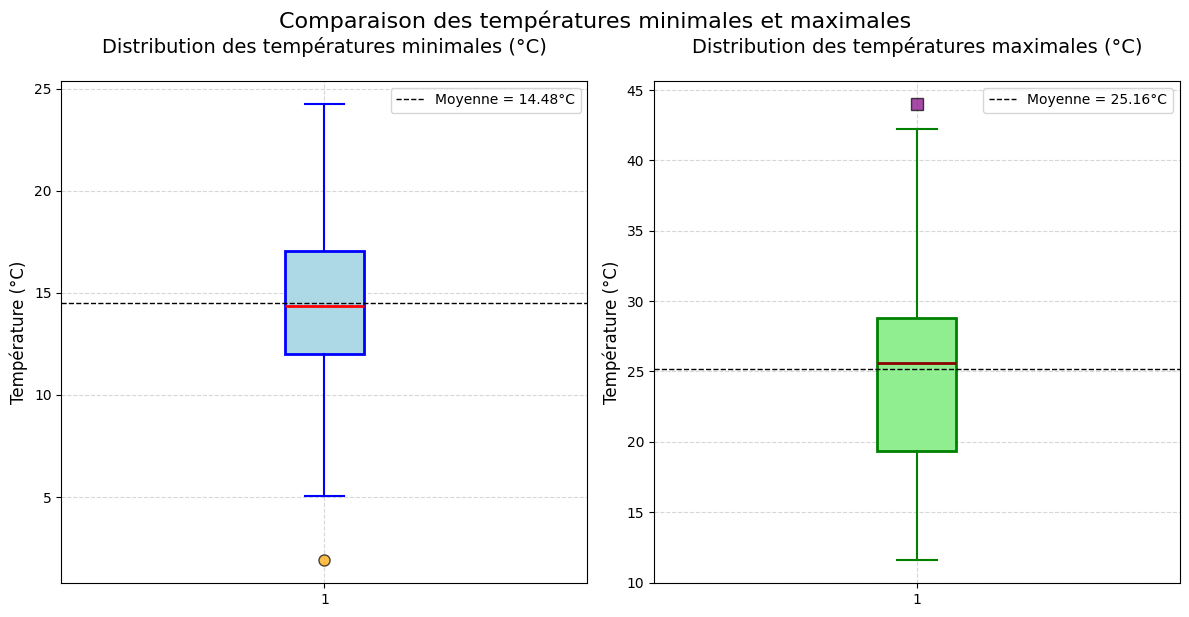

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Exemple de données (à remplacer par df_weather) ---
np.random.seed(42)
df_weather = pd.DataFrame({
    'MIN_TEMPERATURE_C': np.random.normal(15, 5, 100),
    'MAX_TEMPERATURE_C': np.random.normal(25, 7, 100),
    'OPINION': np.random.choice(['Good', 'Bad'], 100),
    'LOCATION': np.random.choice(['Paris', 'Lyon'], 100)
})

# --- Création des boxplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # Taille ajustée

# --- Boxplot pour MIN_TEMPERATURE_C ---
ax1.set_title('Distribution des températures minimales (°C)', fontsize=14, pad=20)
box1 = ax1.boxplot(
    df_weather['MIN_TEMPERATURE_C'],
    patch_artist=True,  # Remplir les boîtes avec une couleur
    boxprops=dict(facecolor='lightblue', color='blue', linewidth=2),  # Style de la boîte
    whiskerprops=dict(color='blue', linewidth=1.5),  # Style des moustaches
    capprops=dict(color='blue', linewidth=1.5),  # Style des caps
    medianprops=dict(color='red', linewidth=2),  # Style de la médiane
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=8, alpha=0.7)  # Style des outliers
)
ax1.set_ylabel('Température (°C)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)  # Grille en pointillés

# --- Boxplot pour MAX_TEMPERATURE_C ---
ax2.set_title('Distribution des températures maximales (°C)', fontsize=14, pad=20)
box2 = ax2.boxplot(
    df_weather['MAX_TEMPERATURE_C'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', color='green', linewidth=2),
    whiskerprops=dict(color='green', linewidth=1.5),
    capprops=dict(color='green', linewidth=1.5),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='s', markerfacecolor='purple', markersize=8, alpha=0.7)
)
ax2.set_ylabel('Température (°C)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Ajouter une ligne pour la moyenne ---
for ax, col in zip([ax1, ax2], ['MIN_TEMPERATURE_C', 'MAX_TEMPERATURE_C']):
    mean = df_weather[col].mean()
    ax.axhline(mean, color='black', linestyle='--', linewidth=1, label=f'Moyenne = {mean:.2f}°C')
    ax.legend(loc='upper right', fontsize=10)

# --- Ajuster la mise en page ---
plt.tight_layout()
plt.suptitle('Comparaison des températures minimales et maximales', fontsize=16, y=1.02)
plt.show()

## Last but not least

We would know if Opinion is a good indicator.
Could you draw 1 scatterplot with :
- DATE on X-axis
- MAX Temperature on Y-axis
- Colorize in green the good and very good points
- Colorize in red the bad and very bad points
- Colorize in yellow the not good not bad points

Tips :
- index attribute of a Series can help you to sort the date correctly
- you may need to stack several graphs based on DataFrame slices

The chart must have a title, a legend for the colors, and of course, readable axis (ticks)

Here is an example of what is expected :

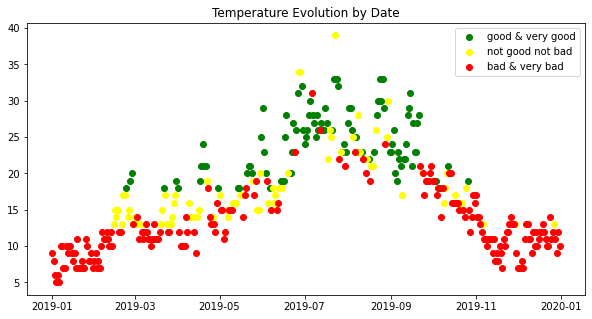

In [ ]:
# It's your turn now :

print(df_weather.index.name)
df_weather.head()
df_weather.sort_values(['DATE'])

Opgood = df_weather[df_weather['OPINION'].isin(['good', 'very good'])]
Opbad = df_weather[df_weather['OPINION'].isin(['bad', 'very bad'])]
Opneutral = df_weather[df_weather['OPINION'] == 'not good not bad']

fig, ax1 = plt.subplots(1, figsize=(14, 6))
ax1.scatter(Opgood["DATE"], Opgood['MAX_TEMPERATURE_C'], color='green', label='Good / Very Good')
ax1.scatter(Opbad["DATE"], Opbad['MAX_TEMPERATURE_C'], color='red', label='Bad / Very Bad')
ax1.scatter(Opneutral["DATE"], Opneutral['MAX_TEMPERATURE_C'], color='yellow', label='Neutral')

ax1.set_xlabel("Date")
ax1.set_ylabel("Température Max (°C)")
ax1.set_title("MAX Temperature vs DATE")
ax1.legend(title="Opinion")
plt.tight_layout()
plt.show()


None


KeyError: 'DATE'